# ASL Hand Gesture Recognition — Full ML Pipeline

Notebook ini mencakup seluruh pipeline Machine Learning untuk klasifikasi gestur tangan ASL (American Sign Language).

Dua pendekatan digunakan secara paralel:
1. **Model CNN** — Transfer learning MobileNetV2 pada gambar tangan
2. **Model Landmark MLP** — MediaPipe hand landmarks → fitur geometris → MLPClassifier

---
**Kelas yang diklasifikasikan:** A–Z (26 huruf) + `del` + `nothing` + `space` = **29 kelas**

## Install Dependencies

In [7]:
# Install dependencies yang diperlukan
# !pip install tensorflow mediapipe scikit-learn joblib pandas matplotlib pillow

## Konfigurasi Global

Semua path, hyperparameter, dan nama kelas didefinisikan di sini.

In [8]:
from pathlib import Path

#   Root directory (sesuaikan dengan struktur project kamu)  
BASE_DIR = Path("D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1").resolve()

#   Direktori Data  
DATA_DIR       = BASE_DIR / "data"
RAW_DIR        = DATA_DIR / "raw"
EXTRACTED_DIR  = DATA_DIR / "extracted"
PROCESSED_DIR  = DATA_DIR / "processed"

TRAIN_DIR      = EXTRACTED_DIR / "train"
TEST_DIR       = EXTRACTED_DIR / "test"

#   Direktori Output  
MODELS_DIR     = BASE_DIR / "models"
REPORTS_DIR    = BASE_DIR / "reports"

#   Hyperparameter CNN  
IMAGE_SIZE     = (224, 224)
BATCH_SIZE     = 32
EPOCHS         = 15
LEARNING_RATE  = 1e-3
RANDOM_SEED    = 42

# a Nama Kelas  
CLASS_NAMES = [
    "A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L",
    "M", "N", "O", "P", "Q", "R", "S", "T",
    "U", "V", "W", "X", "Y", "Z",
    "del", "nothing", "space"
]
NUM_CLASSES = len(CLASS_NAMES)

#   Path Model CNN  
MODEL_PATH     = MODELS_DIR / "best_model.keras"
LABEL_MAP_PATH = MODELS_DIR / "label_map.json"

#   Path Model Landmark  
LANDMARK_MODEL_PATH         = MODELS_DIR / "landmark_mlp.joblib"
LANDMARK_LABEL_MAP_PATH     = MODELS_DIR / "landmark_label_map.json"
LANDMARK_LABEL_ENCODER_PATH = MODELS_DIR / "landmark_label_encoder.joblib"

print(f"✅ Konfigurasi berhasil dimuat")
print(f"   BASE_DIR   : {BASE_DIR}")
print(f"   TRAIN_DIR  : {TRAIN_DIR}")
print(f"   MODELS_DIR : {MODELS_DIR}")
print(f"   NUM_CLASSES: {NUM_CLASSES}")
print(f"   Kelas      : {CLASS_NAMES}")

✅ Konfigurasi berhasil dimuat
   BASE_DIR   : D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1
   TRAIN_DIR  : D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data\extracted\train
   MODELS_DIR : D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models
   NUM_CLASSES: 29
   Kelas      : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Darryl\AppData\Local\Temp\ipykernel_25760\61609238.py:4: SyntaxWarning: invalid escape sequence '\D'
  BASE_DIR = Path("D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1").resolve()


## Utilities

Fungsi pembantu: seed, direktori, JSON I/O.

In [9]:
import json
import random
import numpy as np


def set_seed(seed: int = 42):
    """Set random seed untuk reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass


def ensure_dir(path):
    """Buat direktori jika belum ada."""
    Path(path).mkdir(parents=True, exist_ok=True)


def save_json(data, path):
    """Simpan data ke file JSON."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)


def load_json(path):
    """Load data dari file JSON."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# Set seed global di awal
set_seed(RANDOM_SEED)

# Pastikan direktori output ada
ensure_dir(MODELS_DIR)
ensure_dir(REPORTS_DIR)

print("✅ Utilities siap, seed sudah di-set:", RANDOM_SEED)

✅ Utilities siap, seed sudah di-set: 42


## Data Loading & Exploratory Data Analysis 

Scan folder train, buat dataframe, split stratified train/val, lalu audit distribusi kelas.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from typing import Tuple


def build_train_dataframe(train_dir: Path = TRAIN_DIR) -> pd.DataFrame:
    """
    Scan folder train dan buat dataframe berisi:
    - filepath : path absolut ke gambar
    - label    : nama kelas
    """
    records = []
    for class_name in CLASS_NAMES:
        class_dir = Path(train_dir) / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Class folder not found: {class_dir}")
        for img_path in class_dir.glob("*.jpg"):
            records.append({
                "filepath": str(img_path.resolve()),
                "label"   : class_name,
            })

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No training images found. Check your TRAIN_DIR path.")
    return df


def split_train_val(
    df: pd.DataFrame,
    val_size: float = 0.2,
    random_state: int = RANDOM_SEED
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split dataframe menjadi train dan validation secara stratified.
    """
    train_df, val_df = train_test_split(
        df,
        test_size=val_size,
        stratify=df["label"],
        random_state=random_state,
        shuffle=True,
    )
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    return train_df, val_df


def get_dataframes(
    train_dir: Path = TRAIN_DIR,
    val_size: float = 0.2,
    random_state: int = RANDOM_SEED
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Helper utama: build + split dataframe."""
    full_df = build_train_dataframe(train_dir=train_dir)
    train_df, val_df = split_train_val(full_df, val_size=val_size, random_state=random_state)
    return train_df, val_df


def summarize_dataframe(df: pd.DataFrame, name: str = "dataset") -> pd.DataFrame:
    """Ringkasan jumlah data per kelas."""
    summary = (
        df["label"]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    summary.columns = ["label", "count"]
    print(f"\n===== SUMMARY: {name.upper()} =====")
    print(f"Total samples: {len(df)}")
    print(summary.to_string(index=False))
    return summary


print("✅ Fungsi data loading siap")

✅ Fungsi data loading siap


In [11]:
#   Load dan split dataset  
full_df = build_train_dataframe(train_dir=TRAIN_DIR)
train_df, val_df = split_train_val(full_df)

print(f"Total gambar   : {len(full_df):,}")
print(f"Train split    : {len(train_df):,}")
print(f"Val split      : {len(val_df):,}")
full_df.head()

Total gambar   : 87,000
Train split    : 69,600
Val split      : 17,400


,filepath,label
0,D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...,A
1,D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...,A
2,D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...,A
3,D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...,A
4,D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...,A



===== SUMMARY: TRAIN =====
Total samples: 69600
  label  count
      A   2400
      B   2400
      C   2400
      D   2400
      E   2400
      F   2400
      G   2400
      H   2400
      I   2400
      J   2400
      K   2400
      L   2400
      M   2400
      N   2400
      O   2400
      P   2400
      Q   2400
      R   2400
      S   2400
      T   2400
      U   2400
      V   2400
      W   2400
      X   2400
      Y   2400
      Z   2400
    del   2400
nothing   2400
  space   2400

===== SUMMARY: VALIDATION =====
Total samples: 17400
  label  count
      A    600
      B    600
      C    600
      D    600
      E    600
      F    600
      G    600
      H    600
      I    600
      J    600
      K    600
      L    600
      M    600
      N    600
      O    600
      P    600
      Q    600
      R    600
      S    600
      T    600
      U    600
      V    600
      W    600
      X    600
      Y    600
      Z    600
    del    600
nothing    600
  space    6

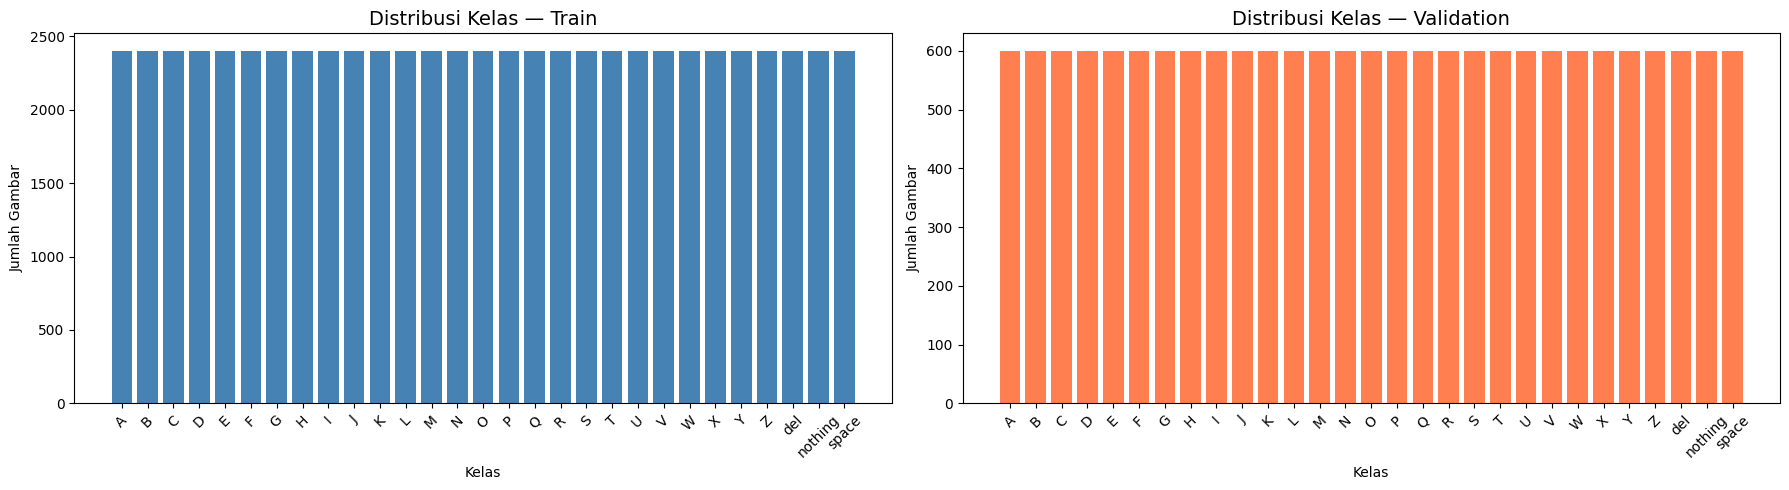

✅ Plot distribusi kelas disimpan


In [12]:
#   Data Audit: Distribusi kelas  
import matplotlib.pyplot as plt

train_summary = summarize_dataframe(train_df, name="Train")
val_summary   = summarize_dataframe(val_df,   name="Validation")

# Plot distribusi
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(train_summary["label"], train_summary["count"], color="steelblue")
axes[0].set_title("Distribusi Kelas — Train", fontsize=14)
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Gambar")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(val_summary["label"], val_summary["count"], color="coral")
axes[1].set_title("Distribusi Kelas — Validation", fontsize=14)
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Gambar")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=150)
plt.show()
print("✅ Plot distribusi kelas disimpan")

In [13]:
#   Audit: cek apakah ada kelas yang hilang / tidak balance  
print("=== Cek Kelas Missing ===")
for cls in CLASS_NAMES:
    n = (full_df["label"] == cls).sum()
    status = "✅" if n > 0 else "❌ MISSING"
    print(f"  {cls:8s}: {n:5d} gambar  {status}")

print(f"\n=== Statistik per Kelas ===")
counts = full_df["label"].value_counts()
print(f"  Min  : {counts.min():5d} ({counts.idxmin()})")
print(f"  Max  : {counts.max():5d} ({counts.idxmax()})")
print(f"  Mean : {counts.mean():.1f}")
print(f"  Std  : {counts.std():.1f}")

=== Cek Kelas Missing ===
  A       :  3000 gambar  ✅
  B       :  3000 gambar  ✅
  C       :  3000 gambar  ✅
  D       :  3000 gambar  ✅
  E       :  3000 gambar  ✅
  F       :  3000 gambar  ✅
  G       :  3000 gambar  ✅
  H       :  3000 gambar  ✅
  I       :  3000 gambar  ✅
  J       :  3000 gambar  ✅
  K       :  3000 gambar  ✅
  L       :  3000 gambar  ✅
  M       :  3000 gambar  ✅
  N       :  3000 gambar  ✅
  O       :  3000 gambar  ✅
  P       :  3000 gambar  ✅
  Q       :  3000 gambar  ✅
  R       :  3000 gambar  ✅
  S       :  3000 gambar  ✅
  T       :  3000 gambar  ✅
  U       :  3000 gambar  ✅
  V       :  3000 gambar  ✅
  W       :  3000 gambar  ✅
  X       :  3000 gambar  ✅
  Y       :  3000 gambar  ✅
  Z       :  3000 gambar  ✅
  del     :  3000 gambar  ✅
  nothing :  3000 gambar  ✅
  space   :  3000 gambar  ✅

=== Statistik per Kelas ===
  Min  :  3000 (A)
  Max  :  3000 (A)
  Mean : 3000.0
  Std  : 0.0


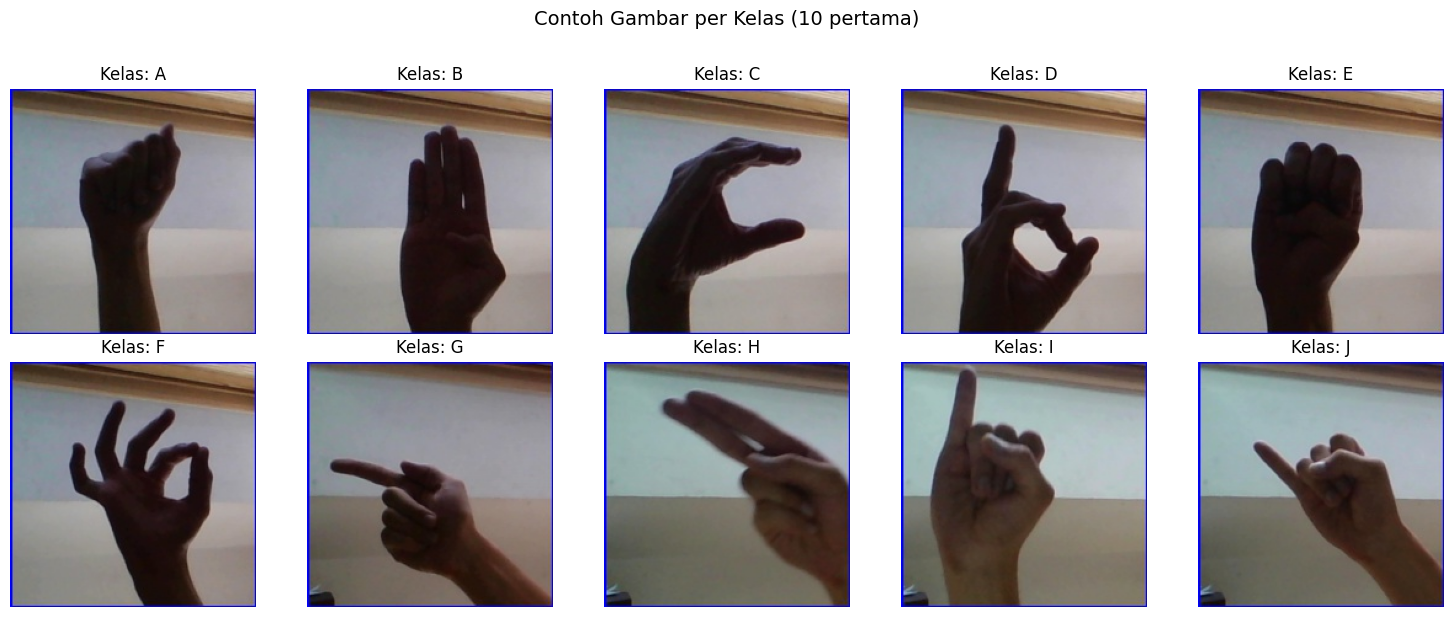

In [14]:
#   Visualisasi contoh gambar per kelas  
from PIL import Image

n_show = min(10, NUM_CLASSES)
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) if n_show >= 10 else plt.subplots(1, n_show, figsize=(3*n_show, 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

shown = 0
for cls in CLASS_NAMES[:n_show]:
    sample = full_df[full_df["label"] == cls].iloc[0]
    img = Image.open(sample["filepath"])
    axes[shown].imshow(img)
    axes[shown].set_title(f"Kelas: {cls}", fontsize=12)
    axes[shown].axis("off")
    shown += 1

plt.suptitle("Contoh Gambar per Kelas (10 pertama)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()


# Model CNN — MobileNetV2 Transfer Learning

## Preprocessing & tf.data Pipeline 

- Encode label string → one-hot
- Load + decode JPEG → resize (224×224) → normalize [0,1]
- Augmentasi ringan (brightness, contrast) untuk train set
- Buat `tf.data.Dataset` dengan batch + prefetch

In [15]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# Mapping label ↔ index
label_to_index = {label: idx for idx, label in enumerate(CLASS_NAMES)}
index_to_label = {idx: label for idx, label in enumerate(CLASS_NAMES)}


def encode_label(label: tf.Tensor) -> tf.Tensor:
    """Ubah label string menjadi index integer via StaticHashTable."""
    keys = tf.constant(list(label_to_index.keys()))
    vals = tf.constant(list(label_to_index.values()), dtype=tf.int32)
    table = tf.lookup.StaticHashTable(
        initializer=tf.lookup.KeyValueTensorInitializer(keys, vals),
        default_value=-1
    )
    return table.lookup(label)


def load_and_preprocess_image(
    filepath: tf.Tensor, label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:
    """Load image dari path, decode JPG, resize, normalize, encode label."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    label_index  = encode_label(label)
    label_onehot = tf.one_hot(label_index, depth=NUM_CLASSES)
    return image, label_onehot


def augment_image(
    image: tf.Tensor, label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:
    """Augmentasi ringan: random brightness + contrast."""
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label


def make_dataset(
    df,
    batch_size: int = BATCH_SIZE,
    training: bool = False
) -> tf.data.Dataset:
    """Ubah dataframe menjadi tf.data.Dataset yang siap dipakai."""
    filepaths = df["filepath"].values
    labels    = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


print("✅ Fungsi preprocessing siap")

✅ Fungsi preprocessing siap


In [16]:
#   Buat tf.data.Dataset  
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, training=True)
val_ds   = make_dataset(val_df,   batch_size=BATCH_SIZE, training=False)

# Verifikasi shape batch
for images, labels in train_ds.take(1):
    print(f"✅ Train dataset OK")
    print(f"   Image batch shape : {images.shape}")
    print(f"   Label batch shape : {labels.shape}")
    print(f"   Pixel value range : [{images.numpy().min():.3f}, {images.numpy().max():.3f}]")

✅ Train dataset OK
   Image batch shape : (32, 224, 224, 3)
   Label batch shape : (32, 29)
   Pixel value range : [-0.124, 1.109]


# Build & Compile Model CNN 

Arsitektur: MobileNetV2 (ImageNet weights, frozen) → GlobalAveragePooling2D → Dropout(0.3) → Dense(29, softmax)

In [17]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


def build_model(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    """
    Build model transfer learning dengan MobileNetV2.
    Base model di-freeze (trainable=False).
    """
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs  = layers.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


def compile_model(model):
    """Compile model dengan Adam optimizer dan categorical crossentropy."""
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def get_callbacks(model_path=MODEL_PATH):
    """
    Callback training:
    - EarlyStopping       : monitor val_loss, patience=5, restore best weights
    - ModelCheckpoint     : simpan model terbaik
    - ReduceLROnPlateau   : kurangi LR jika val_loss stagnan
    """
    Path(model_path).parent.mkdir(parents=True, exist_ok=True)

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]
    return callbacks


def train_model(model, train_ds, val_ds, epochs):
    """Jalankan proses training."""
    callbacks = get_callbacks()
    history   = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )
    return history


#   Inisialisasi model  
cnn_model = build_model(input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
cnn_model = compile_model(cnn_model)

print("✅ Model CNN berhasil dibangun")
cnn_model.summary()

✅ Model CNN berhasil dibangun


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Training Model CNN

In [ ]:
#   Training  
print(f"[INFO] Mulai training CNN — {EPOCHS} epoch maks, early stopping patience=5")
print(f"[INFO] Model akan disimpan ke: {MODEL_PATH}")

cnn_history = train_model(cnn_model, train_ds, val_ds, epochs=EPOCHS)

print("\n✅ Training CNN selesai")

In [22]:
#   Simpan label map CNN  
cnn_label_map = {str(idx): label for idx, label in enumerate(CLASS_NAMES)}
save_json(cnn_label_map, LABEL_MAP_PATH)
print(f"✅ Label map CNN disimpan ke: {LABEL_MAP_PATH}")

✅ Label map CNN disimpan ke: D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\label_map.json


# Evaluasi Model CNN 

- Plot training history (accuracy & loss)
- Classification report
- Confusion matrix

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def plot_training_history(history, save_dir=REPORTS_DIR):
    """Plot accuracy dan loss dari history training."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    hist = history.history

    # Accuracy plot
    plt.figure(figsize=(10, 4))
    plt.plot(hist["accuracy"],     label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / "training_accuracy.png", dpi=150)
    plt.show()

    # Loss plot
    plt.figure(figsize=(10, 4))
    plt.plot(hist["loss"],     label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / "training_loss.png", dpi=150)
    plt.show()


def get_true_and_pred_labels(model, dataset):
    """Ambil y_true dan y_pred dari seluruh dataset."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def show_classification_report(model, dataset, class_names=CLASS_NAMES):
    """Tampilkan classification report."""
    y_true, y_pred = get_true_and_pred_labels(model, dataset)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)
    return y_true, y_pred


def plot_confusion_matrix(model, dataset, class_names=CLASS_NAMES, save_dir=REPORTS_DIR):
    """Plot confusion matrix."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    y_true, y_pred = get_true_and_pred_labels(model, dataset)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix — CNN")
    plt.tight_layout()
    plt.savefig(save_dir / "confusion_matrix_cnn.png", dpi=150)
    plt.show()
    return cm


print("✅ Fungsi evaluasi siap")

✅ Fungsi evaluasi siap


In [21]:
#   Classification Report CNN  
print("===== CLASSIFICATION REPORT — CNN (Validation Set) =====")
cnn_y_true, cnn_y_pred = show_classification_report(cnn_model, val_ds, CLASS_NAMES)

===== CLASSIFICATION REPORT — CNN (Validation Set) =====
              precision    recall  f1-score   support

           A     0.8328    0.4317    0.5686       600
           B     0.8372    0.6000    0.6990       600
           C     0.8960    0.7467    0.8145       600
           D     0.9325    0.7600    0.8375       600
           E     0.4950    0.6550    0.5638       600
           F     0.8846    0.9067    0.8955       600
           G     0.8440    0.7033    0.7673       600
           H     0.9622    0.8067    0.8776       600
           I     0.6327    0.4650    0.5360       600
           J     0.8237    0.6383    0.7192       600
           K     0.5005    0.9100    0.6458       600
           L     0.6840    0.8550    0.7600       600
           M     0.4576    0.7817    0.5772       600
           N     0.7807    0.5933    0.6742       600
           O     0.7298    0.8417    0.7817       600
           P     0.8554    0.5717    0.6853       600
           Q     0.6423 

In [23]:
#   Confusion Matrix CNN  
cnn_cm = plot_confusion_matrix(cnn_model, val_ds, CLASS_NAMES)

KeyboardInterrupt: 


# Model Landmark MLP

Pipeline: **Gambar → MediaPipe Hand Landmarks → Feature Engineering → MLP Classifier (sklearn)**

## Hand ROI Detector (`hand_roi.py`)

Deteksi tangan menggunakan MediaPipe untuk crop ROI sebelum inferensi.

In [ ]:
from __future__ import annotations

import base64
import io
import threading
import urllib.request
from dataclasses import dataclass
from typing import Optional, Tuple

import mediapipe as mp
from PIL import Image, ImageOps


HAND_LANDMARKER_MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
)
HAND_LANDMARKER_MODEL_PATH = MODELS_DIR / "mediapipe" / "hand_landmarker.task"


@dataclass
class HandROIResult:
    ok         : bool
    message    : str
    roi_image  : Optional[Image.Image]           = None
    roi_bbox   : Optional[Tuple[int,int,int,int]] = None
    handedness : Optional[str]                    = None


def ensure_hand_landmarker_model(
    model_path: Path = HAND_LANDMARKER_MODEL_PATH,
    model_url : str  = HAND_LANDMARKER_MODEL_URL,
) -> Path:
    """Download MediaPipe hand landmarker model jika belum ada."""
    model_path = Path(model_path)
    if model_path.exists():
        print(f"  [INFO] Model sudah ada: {model_path}")
        return model_path
    model_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"  [INFO] Mendownload model MediaPipe...")
    urllib.request.urlretrieve(model_url, str(model_path))
    print(f"  [INFO] Model disimpan ke: {model_path}")
    return model_path


def pil_to_data_url(image: Image.Image, quality: int = 90) -> str:
    """Konversi PIL image ke data URL base64 (untuk display di HTML)."""
    buffer  = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{encoded}"


class HandROIDetector:
    """
    Detektor ROI tangan menggunakan MediaPipe Hand Landmarker.
    Mendukung IMAGE mode (single frame) dan VIDEO mode (stream).
    """

    def __init__(
        self,
        margin_ratio                  : float = 0.30,
        min_roi_size                  : int   = 80,
        min_hand_detection_confidence : float = 0.65,
        min_hand_presence_confidence  : float = 0.65,
        min_tracking_confidence       : float = 0.60,
    ):
        self.model_path  = ensure_hand_landmarker_model()
        self.margin_ratio = margin_ratio
        self.min_roi_size = min_roi_size

        self._lock               = threading.Lock()
        self._video_timestamp_ms = 0

        BaseOptions          = mp.tasks.BaseOptions
        HandLandmarker       = mp.tasks.vision.HandLandmarker
        HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
        RunningMode          = mp.tasks.vision.RunningMode

        opts = dict(
            base_options                  = BaseOptions(model_asset_path=str(self.model_path)),
            num_hands                     = 1,
            min_hand_detection_confidence = min_hand_detection_confidence,
            min_hand_presence_confidence  = min_hand_presence_confidence,
            min_tracking_confidence       = min_tracking_confidence,
        )
        self._image_landmarker = HandLandmarker.create_from_options(
            HandLandmarkerOptions(**opts, running_mode=RunningMode.IMAGE)
        )
        self._video_landmarker = HandLandmarker.create_from_options(
            HandLandmarkerOptions(**opts, running_mode=RunningMode.VIDEO)
        )

    def close(self) -> None:
        for landmarker in [self._image_landmarker, self._video_landmarker]:
            close_fn = getattr(landmarker, "close", None)
            if callable(close_fn):
                close_fn()

    def _prepare_pil(self, image: Image.Image) -> Image.Image:
        return ImageOps.exif_transpose(image).convert("RGB")

    def _to_mp_image(self, image: Image.Image) -> mp.Image:
        np_image = np.asarray(image)
        return mp.Image(image_format=mp.ImageFormat.SRGB, data=np_image)

    def _extract_handedness(self, result) -> Optional[str]:
        try:
            return result.handedness[0][0].category_name
        except Exception:
            return None

    def _compute_square_bbox(
        self,
        hand_landmarks,
        width : int,
        height: int,
    ) -> Optional[Tuple[int, int, int, int]]:
        xs = [lm.x for lm in hand_landmarks]
        ys = [lm.y for lm in hand_landmarks]

        x_min = max(0.0, min(xs));  x_max = min(1.0, max(xs))
        y_min = max(0.0, min(ys));  y_max = min(1.0, max(ys))

        box_w = max(1, int((x_max - x_min) * width))
        box_h = max(1, int((y_max - y_min) * height))
        size  = int(max(box_w, box_h) * (1.0 + self.margin_ratio))
        size  = max(size, self.min_roi_size)
        size  = min(size, width, height)

        cx = int(((x_min + x_max) / 2.0) * width)
        cy = int(((y_min + y_max) / 2.0) * height)

        x1 = cx - size // 2;  y1 = cy - size // 2
        x2 = x1 + size;       y2 = y1 + size

        # Clamp ke batas gambar
        if x1 < 0: x2 -= x1; x1 = 0
        if y1 < 0: y2 -= y1; y1 = 0
        if x2 > width:  shift = x2 - width;  x1 -= shift; x2 = width
        if y2 > height: shift = y2 - height; y1 -= shift; y2 = height

        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(width, x2);  y2 = min(height, y2)

        if x2 <= x1 or y2 <= y1:
            return None
        if (x2 - x1) < self.min_roi_size or (y2 - y1) < self.min_roi_size:
            return None
        return int(x1), int(y1), int(x2), int(y2)

    def extract_hand_roi(
        self,
        image           : Image.Image,
        use_video_mode  : bool = False,
    ) -> HandROIResult:
        """Deteksi tangan dan crop ROI berbentuk persegi."""
        prepared       = self._prepare_pil(image)
        width, height  = prepared.size
        mp_image       = self._to_mp_image(prepared)

        with self._lock:
            if use_video_mode:
                self._video_timestamp_ms += 33
                result = self._video_landmarker.detect_for_video(mp_image, self._video_timestamp_ms)
            else:
                result = self._image_landmarker.detect(mp_image)

        if not result.hand_landmarks:
            return HandROIResult(
                ok=False,
                message="No hand detected. Letakkan satu tangan lebih jelas di dalam kotak."
            )

        bbox = self._compute_square_bbox(result.hand_landmarks[0], width, height)
        if bbox is None:
            return HandROIResult(
                ok=False,
                message="Hand detected but ROI is too small. Dekatkan tangan ke kamera."
            )

        roi_image  = prepared.crop(bbox)
        handedness = self._extract_handedness(result)

        return HandROIResult(
            ok=True, message="ok",
            roi_image=roi_image, roi_bbox=bbox, handedness=handedness
        )


print("✅ HandROIDetector siap")

# Landmark Feature Extraction 

Ekstrak **103 fitur** dari 21 landmark tangan MediaPipe:
- **63 fitur**: koordinat (x,y,z) ternormalisasi dari 21 landmark
- **40 fitur extra**: jarak ujung jari, sudut antar-ruas, elevasi jari

In [ ]:
#   Konstanta indeks landmark MediaPipe  
WRIST = 0
THUMB_CMC,  THUMB_MCP,  THUMB_IP,  THUMB_TIP  = 1,  2,  3,  4
INDEX_MCP,  INDEX_PIP,  INDEX_DIP,  INDEX_TIP  = 5,  6,  7,  8
MIDDLE_MCP, MIDDLE_PIP, MIDDLE_DIP, MIDDLE_TIP = 9,  10, 11, 12
RING_MCP,   RING_PIP,   RING_DIP,   RING_TIP   = 13, 14, 15, 16
PINKY_MCP,  PINKY_PIP,  PINKY_DIP,  PINKY_TIP  = 17, 18, 19, 20

FINGERTIPS   = [THUMB_TIP, INDEX_TIP, MIDDLE_TIP, RING_TIP, PINKY_TIP]
FINGER_BONES = [
    (THUMB_CMC,  THUMB_MCP,  THUMB_IP,  THUMB_TIP),
    (INDEX_MCP,  INDEX_PIP,  INDEX_DIP,  INDEX_TIP),
    (MIDDLE_MCP, MIDDLE_PIP, MIDDLE_DIP, MIDDLE_TIP),
    (RING_MCP,   RING_PIP,   RING_DIP,   RING_TIP),
    (PINKY_MCP,  PINKY_PIP,  PINKY_DIP,  PINKY_TIP),
]


def _angle_between(v1: np.ndarray, v2: np.ndarray) -> float:
    """Sudut cosinus (radian) antara dua vektor. Aman untuk vektor nol."""
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-7 or n2 < 1e-7:
        return 0.0
    cos_a = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.arccos(cos_a))


def _build_extra_features(coords: np.ndarray) -> np.ndarray:
    """
    Bangun fitur geometris tambahan dari 21 landmark (21×3 array).

    Output (40 fitur):
    - 5  : jarak wrist ke masing-masing ujung jari (normalized by hand scale)
    - 10 : jarak pairwise antar ujung jari (C(5,2))
    - 5  : jarak masing-masing ujung jari ke INDEX_TIP
    - 15 : sudut tekukan sendi per ruas per jari (3 ruas × 5 jari)
    - 5  : elevasi ujung jari relatif ke MCP (jari lurus vs. menekuk)
    """
    features = []

    # Hand scale: jarak wrist → MIDDLE_MCP
    hand_scale = np.linalg.norm(coords[MIDDLE_MCP, :2] - coords[WRIST, :2])
    hand_scale = max(hand_scale, 1e-6)

    # 5 jarak wrist → ujung jari
    for tip_idx in FINGERTIPS:
        d = np.linalg.norm(coords[tip_idx, :2] - coords[WRIST, :2]) / hand_scale
        features.append(d)

    # 10 jarak pairwise antar ujung jari
    tips = [coords[i, :2] for i in FINGERTIPS]
    for i in range(len(FINGERTIPS)):
        for j in range(i + 1, len(FINGERTIPS)):
            features.append(np.linalg.norm(tips[i] - tips[j]) / hand_scale)

    # 5 jarak ujung jari → INDEX_TIP
    index_tip = coords[INDEX_TIP, :2]
    for tip_idx in [THUMB_TIP, MIDDLE_TIP, RING_TIP, PINKY_TIP, WRIST]:
        features.append(np.linalg.norm(coords[tip_idx, :2] - index_tip) / hand_scale)

    # 15 sudut tekukan sendi (3 ruas × 5 jari)
    for bone_indices in FINGER_BONES:
        for k in range(len(bone_indices) - 2):
            a = coords[bone_indices[k],     :3]
            b = coords[bone_indices[k + 1], :3]
            c = coords[bone_indices[k + 2], :3]
            angle = _angle_between(a - b, c - b)
            features.append(angle / np.pi)  # normalize ke [0,1]

    # 5 elevasi ujung jari relatif ke MCP
    mcp_indices = [THUMB_MCP, INDEX_MCP, MIDDLE_MCP, RING_MCP, PINKY_MCP]
    for tip_idx, mcp_idx in zip(FINGERTIPS, mcp_indices):
        elev = (coords[mcp_idx, 1] - coords[tip_idx, 1]) / hand_scale
        features.append(elev)

    return np.array(features, dtype=np.float32)


class HandLandmarkFeatureExtractor:
    """
    Ekstrak 21 hand landmarks MediaPipe, normalisasi,
    lalu bangun feature vector kaya (103 fitur):
    [0:63]   koordinat (x,y,z) ternormalisasi
    [63:103] fitur geometris (jarak, sudut, elevasi)
    """

    def __init__(
        self,
        min_hand_detection_confidence: float = 0.5,
        min_hand_presence_confidence : float = 0.5,
        min_tracking_confidence      : float = 0.5,
        enable_video_mode            : bool  = False,
    ):
        model_path = ensure_hand_landmarker_model()

        BaseOptions           = mp.tasks.BaseOptions
        HandLandmarker        = mp.tasks.vision.HandLandmarker
        HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
        RunningMode           = mp.tasks.vision.RunningMode

        self.image_landmarker = HandLandmarker.create_from_options(
            HandLandmarkerOptions(
                base_options                  = BaseOptions(model_asset_path=str(model_path)),
                running_mode                  = RunningMode.IMAGE,
                num_hands                     = 1,
                min_hand_detection_confidence = min_hand_detection_confidence,
                min_hand_presence_confidence  = min_hand_presence_confidence,
                min_tracking_confidence       = min_tracking_confidence,
            )
        )

        self.video_landmarker    = None
        self._video_lock         = threading.Lock()
        self._video_timestamp_ms = 0

        if enable_video_mode:
            self.video_landmarker = HandLandmarker.create_from_options(
                HandLandmarkerOptions(
                    base_options                  = BaseOptions(model_asset_path=str(model_path)),
                    running_mode                  = RunningMode.VIDEO,
                    num_hands                     = 1,
                    min_hand_detection_confidence = min_hand_detection_confidence,
                    min_hand_presence_confidence  = min_hand_presence_confidence,
                    min_tracking_confidence       = min_tracking_confidence,
                )
            )

    def close(self) -> None:
        for lm in [self.image_landmarker, self.video_landmarker]:
            if lm is None: continue
            fn = getattr(lm, "close", None)
            if callable(fn): fn()

    def _prepare_image(self, image: Image.Image) -> Image.Image:
        return ImageOps.exif_transpose(image).convert("RGB")

    def _to_mp_image(self, image: Image.Image) -> mp.Image:
        return mp.Image(image_format=mp.ImageFormat.SRGB, data=np.asarray(image))

    def _detect(self, image: Image.Image, use_video_mode: bool = False):
        mp_image = self._to_mp_image(image)
        if use_video_mode and self.video_landmarker is not None:
            with self._video_lock:
                self._video_timestamp_ms += 30
                return self.video_landmarker.detect_for_video(mp_image, self._video_timestamp_ms)
        return self.image_landmarker.detect(mp_image)

    def _extract_raw_landmarks(
        self, image: Image.Image, use_video_mode: bool = False
    ) -> Tuple[Optional[np.ndarray], Optional[str]]:
        image  = self._prepare_image(image)
        result = self._detect(image, use_video_mode=use_video_mode)

        if not result.hand_landmarks:
            return None, None

        coords = np.array(
            [[lm.x, lm.y, lm.z] for lm in result.hand_landmarks[0]],
            dtype=np.float32
        )
        handedness = None
        try:
            handedness = result.handedness[0][0].category_name
        except Exception:
            pass
        return coords, handedness

    def normalize_landmarks(
        self, coords: np.ndarray, handedness: Optional[str] = None
    ) -> np.ndarray:
        """
        Normalisasi 21 landmark:
        1. Mirror tangan kiri → kanan (konsistensi)
        2. Center ke wrist
        3. Scale XY oleh jarak maksimal dari wrist
        4. Normalisasi Z (depth) secara terpisah
        """
        coords = coords.copy()
        if handedness == "Left":
            coords[:, 0] = 1.0 - coords[:, 0]   # mirror X
        wrist    = coords[WRIST].copy()
        coords  -= wrist
        xy_scale = max(np.max(np.linalg.norm(coords[:, :2], axis=1)), 1e-6)
        coords[:, :2] /= xy_scale
        z_range = max(coords[:, 2].max() - coords[:, 2].min(), 1e-6)
        coords[:, 2] = coords[:, 2] / z_range
        return coords.astype(np.float32)

    def extract_features_from_pil(
        self, image: Image.Image, use_video_mode: bool = False
    ) -> Optional[np.ndarray]:
        """
        Pipeline penuh: PIL image → (103,) float32 array.
        Return None jika tidak ada tangan terdeteksi.
        """
        coords, handedness = self._extract_raw_landmarks(image, use_video_mode=use_video_mode)
        if coords is None:
            return None
        norm_coords   = self.normalize_landmarks(coords, handedness=handedness)
        base_features = norm_coords.flatten()              # 63 fitur
        extra_features = _build_extra_features(norm_coords) # 40 fitur
        return np.concatenate([base_features, extra_features]).astype(np.float32)

    def extract_features_from_path(self, image_path: str) -> Optional[np.ndarray]:
        with Image.open(image_path) as image:
            return self.extract_features_from_pil(image, use_video_mode=False)


print("✅ HandLandmarkFeatureExtractor siap")
print(f"   Feature dimension: 63 (coords) + 40 (geometric) = 103")

# Training Landmark MLP

Pipeline:
1. Ekstrak fitur landmark dari dataset
2. Augmentasi landmark (jitter + scale + rotasi 2D)
3. Inject synthetic "nothing" samples sebagai hard negatives
4. Train MLP: `StandardScaler → MLPClassifier(512, 256, 128)`

In [ ]:
import time
import joblib
from typing import Dict, List
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


#   Hyperparameter Augmentasi  
AUGMENT_COPIES   = 3          # salinan augmentasi per sampel real
JITTER_STD       = 0.015      # std noise Gaussian pada coords
SCALE_RANGE      = (0.88, 1.12)  # range random scale
ROTATION_MAX_DEG = 12         # max rotasi 2D (derajat)

# Jumlah sampel sintetis kelas "nothing"
NOTHING_SAMPLES = 800


def _rotate_2d(coords: np.ndarray, angle_rad: float) -> np.ndarray:
    """Rotasi XY dari landmark coords mengelilingi origin."""
    c, s = np.cos(angle_rad), np.sin(angle_rad)
    R    = np.array([[c, -s], [s, c]], dtype=np.float32)
    coords = coords.copy()
    coords[:, :2] = coords[:, :2] @ R.T
    return coords


def augment_landmark_coords(
    coords_21x3: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Augmentasi acak pada array landmark (21,3) yang sudah ternormalisasi:
    1. Gaussian jitter
    2. Random scale
    3. Random rotasi 2D
    """
    coords  = coords_21x3.copy()
    coords += rng.normal(0, JITTER_STD, size=coords.shape).astype(np.float32)
    scale   = rng.uniform(*SCALE_RANGE)
    coords *= scale
    angle   = rng.uniform(-ROTATION_MAX_DEG, ROTATION_MAX_DEG) * (np.pi / 180.0)
    coords  = _rotate_2d(coords, float(angle))
    return coords.astype(np.float32)


def _extract_raw_coords_and_handedness(extractor, filepath: str):
    """Ambil raw landmark coords + handedness sebelum normalisasi."""
    try:
        with Image.open(filepath) as img:
            coords, handedness = extractor._extract_raw_landmarks(img)
        return coords, handedness
    except Exception:
        return None, None


def prepare_landmark_dataset(
    df         : pd.DataFrame,
    extractor  : HandLandmarkFeatureExtractor,
    drop_nothing: bool = False,
    augment    : bool  = False,
    rng        : np.random.Generator = None,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, int]]:
    """
    Bangun feature matrix dari dataframe filepath-label.
    Jika augment=True, tiap sampel real menghasilkan AUGMENT_COPIES salinan.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    feature_list: List[np.ndarray] = []
    label_list  : List[str]        = []
    skipped_by_label: Dict[str, int] = {}

    total      = len(df)
    start_time = time.time()

    for i, (_, row) in enumerate(df.iterrows()):
        label    = row["label"]
        filepath = row["filepath"]

        if drop_nothing and label == "nothing":
            continue

        # Kelas "nothing" → skip extract, akan diganti synthetic negatives
        if label == "nothing":
            skipped_by_label[label] = skipped_by_label.get(label, 0) + 1
            continue

        if augment:
            coords, handedness = _extract_raw_coords_and_handedness(extractor, filepath)
            if coords is None:
                skipped_by_label[label] = skipped_by_label.get(label, 0) + 1
                continue

            # Sampel original
            norm  = extractor.normalize_landmarks(coords, handedness=handedness)
            base  = norm.flatten()
            extra = _build_extra_features(norm)
            feature_list.append(np.concatenate([base, extra]).astype(np.float32))
            label_list.append(label)

            # Salinan augmentasi
            for _ in range(AUGMENT_COPIES):
                aug   = augment_landmark_coords(norm, rng)
                extra = _build_extra_features(aug)
                feature_list.append(np.concatenate([aug.flatten(), extra]).astype(np.float32))
                label_list.append(label)

        else:
            features = extractor.extract_features_from_path(filepath)
            if features is None:
                skipped_by_label[label] = skipped_by_label.get(label, 0) + 1
                continue
            feature_list.append(features)
            label_list.append(label)

        if (i + 1) % 500 == 0:
            elapsed = time.time() - start_time
            print(f"  [{i+1}/{total}] fitur diekstrak | {elapsed:.1f}s")

    if not feature_list:
        raise ValueError("Tidak ada fitur landmark yang berhasil diekstrak.")

    X = np.vstack(feature_list).astype(np.float32)
    y = np.array(label_list)
    return X, y, skipped_by_label


def inject_nothing_samples(
    X          : np.ndarray,
    y          : np.ndarray,
    n_samples  : int,
    rng        : np.random.Generator,
    feature_dim: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Inject sampel sintetis kelas 'nothing' sebagai hard negatives.
    Setengah: pure random noise [-1,1]
    Setengah: sampel real dengan heavy noise
    """
    n_random    = n_samples // 2
    n_perturbed = n_samples - n_random

    random_noise = rng.uniform(-1.0, 1.0, size=(n_random, feature_dim)).astype(np.float32)

    indices   = rng.integers(0, len(X), size=n_perturbed)
    perturbed = X[indices].copy()
    perturbed += rng.normal(0, 0.4, size=perturbed.shape).astype(np.float32)

    nothing_X = np.vstack([random_noise, perturbed]).astype(np.float32)
    nothing_y = np.array(["nothing"] * n_samples)

    return np.vstack([X, nothing_X]), np.concatenate([y, nothing_y])


def build_landmark_pipeline(random_state: int = 42) -> Pipeline:
    """
    Pipeline sklearn:
    StandardScaler → MLPClassifier(512, 256, 128)
    """
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes  = (512, 256, 128),
            activation          = "relu",
            solver              = "adam",
            alpha               = 5e-4,
            batch_size          = 256,
            learning_rate       = "adaptive",
            learning_rate_init  = 1e-3,
            max_iter            = 300,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
            random_state        = random_state,
            verbose             = True,
        )),
    ])


print("✅ Fungsi Landmark MLP training siap")

In [ ]:
#   Inisialisasi extractor & RNG  
print("[INFO] Membuat HandLandmarkFeatureExtractor...")
landmark_extractor = HandLandmarkFeatureExtractor(enable_video_mode=False)
rng_global         = np.random.default_rng(RANDOM_SEED)
print("✅ Extractor siap")

In [ ]:
#   Ekstraksi fitur TRAIN (dengan augmentasi)  
print("[INFO] Mengekstrak fitur landmark TRAIN (dengan augmentasi)...")
print(f"      Setiap sampel real → 1 original + {AUGMENT_COPIES} augmented copies")

X_train_lm, y_train_lm_str, train_skipped = prepare_landmark_dataset(
    train_df, landmark_extractor,
    drop_nothing=False, augment=True, rng=rng_global
)
feature_dim = X_train_lm.shape[1]

print(f"\n[INFO] X_train shape (setelah augmentasi): {X_train_lm.shape}")
print(f"[INFO] Skipped TRAIN by label: {train_skipped}")

In [ ]:
#   Inject synthetic "nothing" samples ke TRAIN  
print(f"[INFO] Injecting {NOTHING_SAMPLES} sampel sintetis 'nothing' ke train...")
X_train_lm, y_train_lm_str = inject_nothing_samples(
    X_train_lm, y_train_lm_str, NOTHING_SAMPLES, rng_global, feature_dim
)
print(f"[INFO] X_train shape (setelah inject nothing): {X_train_lm.shape}")

In [ ]:
#   Ekstraksi fitur VAL (tanpa augmentasi)  
print("[INFO] Mengekstrak fitur landmark VAL (tanpa augmentasi)...")
X_val_lm, y_val_lm_str, val_skipped = prepare_landmark_dataset(
    val_df, landmark_extractor,
    drop_nothing=False, augment=False
)

# Inject nothing ke val juga (skala lebih kecil)
X_val_lm, y_val_lm_str = inject_nothing_samples(
    X_val_lm, y_val_lm_str, NOTHING_SAMPLES // 5, rng_global, feature_dim
)
print(f"[INFO] X_val shape: {X_val_lm.shape}")
print(f"[INFO] Skipped VAL by label: {val_skipped}")

In [ ]:
#   Encode label → integer  
print("[INFO] Encoding labels...")
label_encoder = LabelEncoder()
y_train_lm    = label_encoder.fit_transform(y_train_lm_str)
y_val_lm      = label_encoder.transform(y_val_lm_str)

lm_class_names = list(label_encoder.classes_)
print(f"[INFO] Kelas ({len(lm_class_names)}): {lm_class_names}")

In [ ]:
#   Training MLP Classifier  
print("[INFO] Memulai training Landmark MLP...")
print("      Arsitektur: StandardScaler → MLP(512, 256, 128, relu, adam)")

landmark_clf = build_landmark_pipeline(random_state=RANDOM_SEED)
landmark_clf.fit(X_train_lm, y_train_lm)

print("\n✅ Training Landmark MLP selesai")

# Evaluasi Landmark MLP

In [ ]:
#   Classification Report Landmark MLP  
y_pred_lm = landmark_clf.predict(X_val_lm)

print("===== CLASSIFICATION REPORT — Landmark MLP (Validation Set) =====")
print(
    classification_report(
        y_val_lm, y_pred_lm,
        target_names=lm_class_names,
        digits=4
    )
)

In [ ]:
#   Confusion Matrix Landmark MLP  
cm_lm = confusion_matrix(y_val_lm, y_pred_lm)

fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lm, display_labels=lm_class_names)
disp.plot(ax=ax, xticks_rotation=90, cmap="Greens", colorbar=False)
plt.title("Confusion Matrix — Landmark MLP")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix_landmark_mlp.png", dpi=150)
plt.show()

In [ ]:
#   Plot MLP Loss Curve  
mlp_estimator = landmark_clf.named_steps["mlp"]

plt.figure(figsize=(10, 4))
plt.plot(mlp_estimator.loss_curve_, label="Training Loss")
if hasattr(mlp_estimator, "validation_scores_") and mlp_estimator.validation_scores_:
    plt.plot(mlp_estimator.validation_scores_, label="Val Score")
plt.title("Landmark MLP — Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "landmark_mlp_loss_curve.png", dpi=150)
plt.show()

# Simpan Model Landmark

In [ ]:
#   Simpan model, label encoder, dan label map  
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(landmark_clf,    LANDMARK_MODEL_PATH)
joblib.dump(label_encoder,   LANDMARK_LABEL_ENCODER_PATH)

lm_label_map = {str(i): label for i, label in enumerate(lm_class_names)}
save_json(lm_label_map, LANDMARK_LABEL_MAP_PATH)

print(f"✅ Landmark model disimpan     : {LANDMARK_MODEL_PATH}")
print(f"✅ Label encoder disimpan      : {LANDMARK_LABEL_ENCODER_PATH}")
print(f"✅ Label map disimpan          : {LANDMARK_LABEL_MAP_PATH}")
print(f"   Feature dimension           : {feature_dim}")

# Cleanup extractor
landmark_extractor.close()

# Inference CNN
Fungsi-fungsi untuk prediksi pada gambar baru menggunakan kedua model.

In [ ]:
from typing import Dict, List


def load_trained_model(model_path=MODEL_PATH):
    """Load model CNN dari file."""
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    return tf.keras.models.load_model(model_path)


def load_label_map(label_map_path=LABEL_MAP_PATH):
    """Load label map dari file JSON."""
    label_map_path = Path(label_map_path)
    if not label_map_path.exists():
        raise FileNotFoundError(f"Label map not found: {label_map_path}")
    return load_json(label_map_path)


def preprocess_pil_image(image: Image.Image, image_size=IMAGE_SIZE) -> np.ndarray:
    """Preprocess PIL image untuk CNN inference."""
    image       = image.convert("RGB").resize(image_size)
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    return np.expand_dims(image_array, axis=0)


def preprocess_image_path(image_path: str, image_size=IMAGE_SIZE) -> np.ndarray:
    with Image.open(image_path) as image:
        return preprocess_pil_image(image, image_size=image_size)


def _predict_probs(model, image_array: np.ndarray) -> np.ndarray:
    return model.predict(image_array, verbose=0)[0]


def predict_image(model, image_path: str, label_map: Dict[str, str]) -> Dict:
    """Prediksi kelas dari path gambar. Return label + confidence."""
    image_array = preprocess_image_path(image_path)
    preds       = _predict_probs(model, image_array)
    pred_idx    = int(np.argmax(preds))
    return {"label": label_map[str(pred_idx)], "confidence": float(preds[pred_idx])}


def predict_pil_image(model, image: Image.Image, label_map: Dict[str, str]) -> Dict:
    """Prediksi kelas dari PIL image."""
    image_array = preprocess_pil_image(image)
    preds       = _predict_probs(model, image_array)
    pred_idx    = int(np.argmax(preds))
    return {"label": label_map[str(pred_idx)], "confidence": float(preds[pred_idx])}


def predict_top_k(
    model, image_path: str, label_map: Dict[str, str], k: int = 3
) -> List[Tuple[str, float]]:
    """Prediksi top-k kelas dari path gambar."""
    image_array = preprocess_image_path(image_path)
    preds       = _predict_probs(model, image_array)
    top_indices = np.argsort(preds)[::-1][:k]
    return [(label_map[str(int(i))], float(preds[i])) for i in top_indices]


def predict_pil_top_k(
    model, image: Image.Image, label_map: Dict[str, str], k: int = 3
) -> List[Tuple[str, float]]:
    """Prediksi top-k kelas dari PIL image."""
    image_array = preprocess_pil_image(image)
    preds       = _predict_probs(model, image_array)
    top_indices = np.argsort(preds)[::-1][:k]
    return [(label_map[str(int(i))], float(preds[i])) for i in top_indices]


print("✅ Fungsi inference CNN siap")

# Inference Landmark MLP

In [ ]:
# Threshold confidence minimum — di bawah ini, output ke "nothing"
LOW_CONFIDENCE_THRESHOLD = 0.45


def load_landmark_model(model_path=LANDMARK_MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Landmark model not found: {model_path}")
    return joblib.load(model_path)


def load_landmark_label_encoder(label_encoder_path=LANDMARK_LABEL_ENCODER_PATH):
    label_encoder_path = Path(label_encoder_path)
    if not label_encoder_path.exists():
        raise FileNotFoundError(f"Landmark label encoder not found: {label_encoder_path}")
    return joblib.load(label_encoder_path)


class LandmarkSmoother:
    """
    Exponential Moving Average (EMA) pada output probabilitas model landmark.
    Digunakan untuk smoothing pada live inference (stream).

    alpha tinggi → lebih reaktif (ikuti frame saat ini)
    alpha rendah → lebih smooth (andalkan riwayat)
    """

    def __init__(self, alpha: float = 0.4, num_classes: Optional[int] = None):
        self.alpha       = alpha
        self._ema        = None
        self._num_classes = num_classes

    def reset(self) -> None:
        self._ema = None

    def update(self, probs: np.ndarray) -> np.ndarray:
        if self._ema is None:
            self._ema = probs.copy()
        else:
            self._ema = self.alpha * probs + (1.0 - self.alpha) * self._ema
        return self._ema.copy()

    def current(self) -> Optional[np.ndarray]:
        return self._ema.copy() if self._ema is not None else None


def predict_landmark_pil(
    model,
    label_encoder,
    extractor  : HandLandmarkFeatureExtractor,
    image      : Image.Image,
    top_k      : int  = 3,
    use_video_mode: bool = False,
    smoother   : Optional[LandmarkSmoother] = None,
) -> Dict:
    """
    Inference lengkap pada satu PIL image menggunakan model Landmark MLP.

    Returns:
        dict berisi: label, confidence, topk, used_landmarks, hand_detected
    """
    features = extractor.extract_features_from_pil(image, use_video_mode=use_video_mode)

    if features is None:
        # Tidak ada tangan terdeteksi
        if smoother is not None:
            smoother.reset()
        return {
            "label"         : "nothing",
            "confidence"    : 1.0,
            "topk"          : [{"label": "nothing", "confidence": 1.0}],
            "used_landmarks": False,
            "hand_detected" : False,
        }

    # Probabilitas mentah dari MLP
    raw_probs = model.predict_proba([features])[0]

    # EMA smoothing (opsional, untuk live inference)
    probs = smoother.update(raw_probs) if smoother is not None else raw_probs

    top_indices = np.argsort(probs)[::-1][:top_k]
    topk = [
        {"label": str(label_encoder.inverse_transform([int(i)])[0]), "confidence": float(probs[i])}
        for i in top_indices
    ]

    best_label = topk[0]["label"]
    best_conf  = topk[0]["confidence"]

    # Low confidence gate: jika terlalu tidak yakin → output "nothing"
    if best_conf < LOW_CONFIDENCE_THRESHOLD and best_label != "nothing":
        best_label = "nothing"
        best_conf  = 1.0 - best_conf

    return {
        "label"         : best_label,
        "confidence"    : best_conf,
        "topk"          : topk,
        "used_landmarks": True,
        "hand_detected" : True,
    }


print("✅ Fungsi inference Landmark MLP siap")

# Demo Inference — Contoh Prediksi pada Gambar Test

In [ ]:
#   Load model dan label map  
loaded_cnn_model  = load_trained_model(MODEL_PATH)
cnn_label_map_loaded = load_label_map(LABEL_MAP_PATH)
print("✅ CNN model dan label map berhasil di-load")

In [ ]:
#   Load Landmark MLP model  
loaded_lm_clf     = load_landmark_model(LANDMARK_MODEL_PATH)
loaded_lm_encoder = load_landmark_label_encoder(LANDMARK_LABEL_ENCODER_PATH)
lm_extractor_demo = HandLandmarkFeatureExtractor(enable_video_mode=False)
print("✅ Landmark MLP model, encoder, dan extractor siap")

In [ ]:
#   Demo: Prediksi beberapa gambar dari validation set  
n_demo = 6
demo_samples = val_df.sample(n=n_demo, random_state=RANDOM_SEED)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(demo_samples.iterrows()):
    filepath    = row["filepath"]
    true_label  = row["label"]

    img = Image.open(filepath)

    # Prediksi CNN
    cnn_result = predict_pil_image(loaded_cnn_model, img, cnn_label_map_loaded)

    # Prediksi Landmark MLP
    lm_result = predict_landmark_pil(
        loaded_lm_clf, loaded_lm_encoder, lm_extractor_demo, img, top_k=1
    )

    # Plot
    axes[i].imshow(img)
    axes[i].axis("off")

    cnn_info = f"CNN: {cnn_result['label']} ({cnn_result['confidence']:.2f})"
    lm_info  = f"LM : {lm_result['label']} ({lm_result['confidence']:.2f})"
    color    = "green" if cnn_result["label"] == true_label else "red"

    axes[i].set_title(
        f"True: {true_label}\n{cnn_info}\n{lm_info}",
        fontsize=9, color=color
    )

plt.suptitle("Demo Inference — CNN vs Landmark MLP\n(hijau=benar, merah=salah)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "demo_inference.png", dpi=150)
plt.show()

# Cleanup
lm_extractor_demo.close()

# Ringkasan 

In [ ]:
from sklearn.metrics import accuracy_score

print("=" * 60)
print("       RINGKASAN HASIL TRAINING ASL RECOGNITION")
print("=" * 60)

print(f"\nDataset")
print(f"   Kelas         : {NUM_CLASSES}")
print(f"   Total gambar  : {len(full_df):,}")
print(f"   Train         : {len(train_df):,}")
print(f"   Validation    : {len(val_df):,}")

print(f"\nModel A — CNN (MobileNetV2 Transfer Learning)")
print(f"   Input size    : {IMAGE_SIZE}")
cnn_val_acc = max(cnn_history.history.get('val_accuracy', [0]))
print(f"   Best val acc  : {cnn_val_acc:.4f} ({cnn_val_acc*100:.2f}%)")
print(f"   Model saved   : {MODEL_PATH}")

print(f"\nModel B — Landmark MLP (MediaPipe + sklearn)")
print(f"   Feature dim   : {feature_dim}")
print(f"   Architecture  : StandardScaler → MLP(512,256,128)")
lm_val_acc = accuracy_score(y_val_lm, y_pred_lm)
print(f"   Val accuracy  : {lm_val_acc:.4f} ({lm_val_acc*100:.2f}%)")
print(f"   Model saved   : {LANDMARK_MODEL_PATH}")

print(f"\nReports disimpan di: {REPORTS_DIR}")
print("=" * 60)